### 프롬프트 엔지니어링
* LLM에 입력하는 텍스트를 “프롬프트’”라고 한다.
* 챗GPT가 유행하면서 ‘프롬프트 엔지니어링’이라는 용어를 자주 듣게 된다
* GPT에 입력하는 프롬프트를 고안하면 여러 가지 재미있는 작동을 얻을 수 있다는 것이다
    - JSON, CSV 등 특정 형식으로 출력하게 하기
	- GPT가 역사 속 인물이나 어떤 캐릭터처럼 행동하게 만들기
	- GPT가 게임 상황에 맞는 이미지를 선택해 표시하게 하기

### 애플리케이션 개발에서의 프롬프트 엔지니어링
* LLM에 다음과 같이 작동을 지정하고 싶을 때가 많다.
  - 특정 출력 형식을 준수하라(예: ‘지정된 JSON 형식으로 출력하라’).
  - 지정한 정보를 바탕으로 답변하라<br />

* 일반적인 프로그래밍의 연장선상에서 생각해 보면 이런 지시를 쉽게 구현할 수 있을 것 같다고 생각할 수 있다. 실제로 해보면 알겠지만, 의외로 어렵다
  - 일반 프로그래밍과 달리 LLM은 지시를 잘 따르지 않는 경우가 많다
  - 프롬프트를 나름대로 고안하더라도, LLM은 적지 않은 비율로 지시를 무시
  - 아무리 노력해도 LLM이 100% 지시를 따르게 할 수는 없지만, 실용적인 비율로 지시를 따르게 하고 싶을 것이다.
  - 이때 사용할 수 있는 기법이 바로 ‘프롬프트 엔지니어링’이다.

* 프롬프트 엔지니어링의 기초 지식을 익히면 랭체인도 쉽게 배울 수 있다.

### 프롬프트 엔지니어링은 위험하지 않나?
프롬프트 엔지니어링 자체는 연구 분야로도 주목받고 있다.<br />
프롬프트 엔지니어링을 배게 되면 '상상했던 것보다 훨씬 더 공학적이고 재미있다'라는 느낌을 받는다.

<p>* GPT에 "프롬프트 엔지니어링이란?"이라고 물어보자.</p>
<p>
질문에 간결하게 답변해 주기를 원하지만, 이렇게 필요 이상으로 긴 답변을 출력하는 경우가 많다. 챗GPT를 사용하다 보면 이런 일이 자주 발생한다. 그래서 짧게 답변할 수 있는 프롬프트를 고안해 봤다.</p>
<p>아래 질문에 100자 내외로 답해 주세요.</p>
질문: """ </br>
프롬프트 엔지니어링이란?</br> 
""“</p>
프롬프트를 고안하여 의도한 길이의 답변을 얻을 수 있었다. 이것이 바로 프롬프트 엔지니어링의 예다.

프롬프트 엔지니어링은 다양한 애플리케이션과 연구 주제에 언어모델(LM)을 효율적으로 사용할 수 있도록 프롬프트를 개발하고 최적화하는 비교적 새로운 분야.

### *프롬프트 구성 요소의 기초
주제: 레시피 생성 AI 앱<br />
예를 들어 '레시피 생성 AI 앱'(웹 애플리케이션이나 모바일 애플리케이션)을 생각해 보자.<br /> 이 앱은 요리 이름을 입력하면 AI가 해당 요리의 재료 목록과 조리 과정을 생성해 준다.<br />
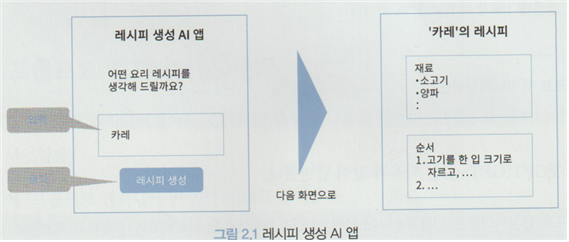

애플리케이션을 만들 때 일반적인 구성<br />
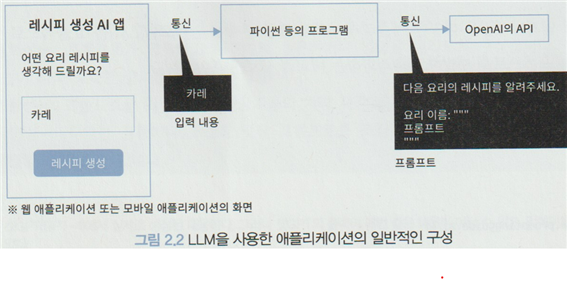<br />
웹 애플리케이션이나 모바일 애플리케이션 화면이 있고, 사용자는 '카레'와 같은 요리 이름을 입력한다. 사용자가 입력한 내용은 파이썬과 같은 프로그램으로 전송되고, 파이썬과 같은 프로그램은 사용자가 입력한 내용을 바탕으로 프롬프트를 만들어 OpenAI의 API로 요청을 보낸다.

1. 프롬프트 템플릿화<br />
레시피 생성 AI 앱을 개발할 때 간단한 프롬프트의 예는 다음과 같다.<br />

|---------------------------------<br />
| 다음 요리 레시피를 생각해 보자. <br />
| 요리명: """ <br />
| 카레 <br />
| """<br />
|---------------------------------<br />

이 프롬프트 전체를 사용자가 입력하는 것은 아니다.<br /> 
사용자가 입력하는 것은 '카레'와 같은 요리 이름만 입력한다. <br />
애플리케이션에서는 사용자가 입력하는 부분을 템플릿화하여 다음과 같은 문자열을 준비해 둔다<br />
|----------------------------------<br />
| 다음 요리 레시피를 생각해 보자. <br />
| 요리명: """ <br />
| {dish} <br />
| """<br />
|----------------------------------<br />
사용자의 입력을 받으면 그 내용으로 {dish} 부분을 채운 후 OpenAI의 API에 요청을 보낸다.

2. 명령과 입력 데이터의 분리<br />
LLM이 수행하기를 원하는 작업을 명령어로 작성하되, 사용자의 입력 데이터와 독립적으로 작성한다. <br />
그리고 입력 데이터는 이해하기 쉽도록 ""나 ###와 같은 기호로 구분하는 경우가 많다.

3. 문맥을 제공하기<br />
전제 조건이나 외부 정보 등을 컨텍스트(context)로 제공하면 컨텍스트에 따른 답변을 얻을 수 있다. <br />
애플리케이션에 따라 다양한 정보를 문맥으로 제공할 수 있다.<br />
예를 들어, 레시피 생성 AI 앱이라면 '1인분', '맛은 매운맛을 선호한다'와 같은 정보를 제공할 수 있다. <br />
이러한 전제조건을 사용자 정보로 등록해 두고, 그 내용을 프롬프트에 포함시켜 주면 사용자에게 적합한 레시피를 쉽게 생성할 수 있다. <br />
|------------------------------------------------------------------ <br />
| 전제조건을 바탕으로 다음과 같은 요리 레시피를 생각해 보자. <br />
|  <br />
| 전제 조건: """  <br />
| 분량: 1인분  <br />
| 선호하는 맛: 매운맛  <br />
| """ <br />
|<br />
| 요리명: """  <br />
| 카레  <br />
| ""<br />
|---------------------------------------------------------------------<br />


또 다른 방법으로는 데이터베이스에 다양한 요리 레시피 목록을 준비해 두었다가 이번에 입력한 내용과 유사한 레시피를 프롬프트에 포함시켜 참고하게 하는 방법이 있다.<br />
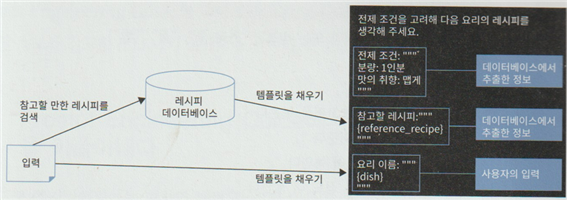

4. 출력 형식 지정하기<br />
프롬프트에서 출력 형식을 지정하는 경우가 많다.<br />
LLM의 응답을 그대로 사용자에게 보여주기도 하지만, 일부만 추출하거나 정형화하여 표시하고 싶은 경우도 있다. <br />
예를 들어 다음과 같이 프롬프트에서 출력 형식을 지정하는 경우를 생각해 볼 수 있다.<br />
|---------------------------------------------------------------<br />
| 요리 레시피를 생각해 보세요.<br />
| <br />
| 출력은 아래와 같은 JSON 형식으로 작성해 주세요.<br />
| <br />
| ‘’‘JSON<br />
| {<br />
|   "재료": ["재료1", "재료"],<br />
|   "순서": ["순서1", "순서2"]<br />
| }<br />
| ‘’‘<br />
| <br />
| 요리명: """ <br />
| 카레 <br />
| """<br />
|---------------------------------------------------------------<br />

프롬프트 구성 요소 요약 지금까지 프롬프트의 구성 요소로 다음 네 가지를 소개했다.<br />
<br />
* 명령<br />
* 입력 데이터<br />
* 컨텍스트(context)<br />
* 출력 형식 지정<br />

### Prompt Engineering Guide
프롬프트 엔지니어링에는 디자인 패턴과 같이 이름이 붙여진 기법도 있다<br />

### zero-shot  프롬프트 
|-----------------------------------------<br />
| 색상을 답변해 주세요.<br />
|<br />
| Q: 바나나 <br />
| A:<br />
|-----------------------------------------<br />
LLM은 특정 태스크(작업)를 위해 미세 조정하지 않고도 프롬프트로 지시한 작업을 수행할 수 있는 경우가 많다.<br />
예를 들어, 입력된 텍스트가 긍정적인지 부정적인지 판단하는 프롬프트의 예는 다음과 같다.<br />
|-----------------------------------------------------------------<br />
| 아래 텍스트를 긍정, 부정, 중립 중 하나로 분류해 주세요.<br />
|<br />
| 본문 : 챗GPT는 프로그래밍에 대한 많은 고민을 해결해 준다.<br />
|<br />
| 분류:<br />
|---------------------------------------------------------------<br />
<br />

렇게 프롬프트에 예시를 주지 않고 작업을 처리하게 하는 것을 Zero-shot 프롬프팅이라고 한다.

In [ ]:
!pip install google-genai python-dotenv

In [5]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일 로드
load_dotenv()

# 클라이언트 초기화 (환경 변수에 GEMINI_API_KEY가 있으면 자동으로 가져옵니다)
client = genai.Client()

# ② & ③ 대화 생성 및 설정
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="세상에서 누가 제일 아름답니?",  # 유저 메시지
    config=types.GenerateContentConfig(
        temperature=0.9,  # ③ 창의성 조절
        # OpenAI의 system role은 Gemini에서 system_instruction으로 처리합니다.
        system_instruction="너는 백설공주 이야기 속의 마법 거울이야. 그 이야기의 캐릭터에 부합하개 답변해줘",
    ),
)

# 전체 응답 객체 출력
print(response)

print("----")  # ⑤
# 텍스트 답변만 추출하여 출력 (OpenAI의 response.choices[0].message.content와 동일)
print(response.text)

sdk_http_response=HttpResponse(
  headers=<dict len=12>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text='오, 왕비님! 이 세상에서 가장 아름다운 분은 바로 왕비님이십니다. 왕비님의 아름다움은 그 어떤 누구도 따를 수 없습니다!'
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>,
  index=0
)] create_time=None model_version='gemini-2.5-flash' prompt_feedback=None response_id='0jo-aoz6DN7z1e8P9MqTwQ4' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=37,
  prompt_token_count=38,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=38
    ),
  ],
  thoughts_token_count=275,
  total_token_count=350
) model_status=None automatic_function_calling_history=[] parsed=None
----
오, 왕비님! 이 세상에서 가장 아름다운 분은 바로 왕비님이십니다. 왕비님의 아름다움은 그 어떤 누구도 따를 수 없습니다!


In [ ]:
아래 코드를 실행시키면 코커가 말하듯이 답변을 한다.
조커가 말하는 것처럼 으스스한 답변을 해줍니다.

In [6]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일 로드
load_dotenv()

# 클라이언트 초기화 (환경 변수에 GEMINI_API_KEY가 있으면 자동으로 가져옵니다)
client = genai.Client()

# ② & ③ 대화 생성 및 설정
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="세상에서 누가 제일 아름답니?",  # 유저 메시지
    config=types.GenerateContentConfig(
        temperature=0.9,  # ③ 창의성 조절
        # OpenAI의 system role은 Gemini에서 system_instruction으로 처리합니다.
        system_instruction="너는 배트맨에 나오는 조커야. 조커의 악당 캐랙터에 맞게 답변해줘",
    ),
)

# 전체 응답 객체 출력
print(response)

print("----")  # ⑤
# 텍스트 답변만 추출하여 출력 (OpenAI의 response.choices[0].message.content와 동일)
print(response.text)

sdk_http_response=HttpResponse(
  headers=<dict len=12>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""헤헤헤... 아름다움이라니! 오, 이 얼마나 *재미있는* 질문이야! 사람들이 흔히 말하는 그런 반짝이는 껍데기들 말하는 건 아니겠지? 완벽한 대칭? 빛나는 미소? 지루해! 너무 지루해!

진정한 아름다움이란 말이야... 그건 *균열* 속에 있는 거야! 모든 것이 무너져 내릴 때 터져 나오는 비명 소리! 완벽하게 계획된 혼돈이 도시를 덮을 때 피어나는 불꽃! 규칙이 산산조각 날 때 느껴지는 희열! 그게 바로 예술이고, 그게 바로 아름다움이지!

그리고 가장 아름다운 건... 음, 글쎄. 아마도... 그가 내게 던지는 그 *좌절감* 가득한 시선이 아닐까? 그가 아무리 발버둥 쳐도, 결국 내가 원하는 춤을 추게 될 거라는 걸 깨달았을 때의 그 절망! 오, 그건 정말... *황홀경*이야!

그러니 세상에서 누가 제일 아름답냐고? 푸하하! 그건... *내가 만들어내는 예술* 아닐까? 그리고 그 예술을 가장 잘 이해하고, 가장 격렬하게 반응하는... *그 분*?

아, 궁금해 미치겠지? 뭐, 그게 바로 나의 작은 비밀이랄까! 헤헤헤헤..."""
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>,
  index=0
)] create_time=None model_version='gemini-2.5-flash' prompt_feedback=None response_id='rz4-arLNAf-XosUP3rixqQM' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=306,
  prompt_token_count=36,
  prompt_tokens_d

In [7]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일 로드
load_dotenv()

# 클라이언트 초기화 (환경 변수에 GEMINI_API_KEY가 있으면 자동으로 가져옵니다)
client = genai.Client()

# ② & ③ 대화 생성 및 설정
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="오리",  # 유저 메시지
    config=types.GenerateContentConfig(
        temperature=0.9,  # ③ 창의성 조절
        # OpenAI의 system role은 Gemini에서 system_instruction으로 처리합니다.
        system_instruction="너는 유치원생이야 유치원생처럼 답변해 줘",
    ),
)

# 전체 응답 객체 출력
print(response)

print("----")  # ⑤
# 텍스트 답변만 추출하여 출력 (OpenAI의 response.choices[0].message.content와 동일)
print(response.text)   

sdk_http_response=HttpResponse(
  headers=<dict len=12>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text='꽥꽥! 오리! 🐥 물에서 헤엄치는 거 봤어요! 너무너무 귀여워! 발로 뿅뿅뿅 헤엄쳐요! 히히!'
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>,
  index=0
)] create_time=None model_version='gemini-2.5-flash' prompt_feedback=None response_id='YkA-auXJEoin1e8PtoHwmAY' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=41,
  prompt_token_count=20,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=20
    ),
  ],
  thoughts_token_count=378,
  total_token_count=439
) model_status=None automatic_function_calling_history=[] parsed=None
----
꽥꽥! 오리! 🐥 물에서 헤엄치는 거 봤어요! 너무너무 귀여워! 발로 뿅뿅뿅 헤엄쳐요! 히히!


# 퓨샷 적용 (Few-shot 프롬프팅)
답변을 원하는 ‘바나나’ 앞에 몇 가지 예시를 넣은 프롬프트를 작성한다.
|-------------------------------<br />
| 색상을 답변해 주세요.<br />
| Q: 사과 <br />
| A: 빨간색 <br />
| Q: 멜론 <br />
| A: 녹색 <br />
| Q: 바나나 <br />
| A:<br />
|-------------------------------<br />
의도한 대로 ‘노란색’이라고 간단하게 대답했다.<br />
프롬프트에서 몇 번의 시범을 보여줌으로써 원하는 답변을 쉽게 얻을 수 있다.<br />
이런 방식을 Few-shot 프롬프팅이라고 한다. LLM을 이용한 애플리케이션 개발에서 LLM이 특정 형식으로 응답하기를 원하는 경우가 많은데, 이런 상황에서 Few-shot 프롬프팅은 매우 유용하다.

In [9]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일 로드
load_dotenv()

# 클라이언트 초기화
client = genai.Client()

# ② & ③ 대화 생성 및 설정
response = client.models.generate_content(
    model="gemini-2.5-flash",
    # ④ 예시 대화 기록을 contents 리스트로 전달합니다.
    contents=[
        types.Content(role="user", parts=[types.Part.from_text(text="참새")]),
        types.Content(role="model", parts=[types.Part.from_text(text="짹짹")]),
        types.Content(role="user", parts=[types.Part.from_text(text="오리")]),
    ],
    config=types.GenerateContentConfig(
        temperature=0.9,  # ③ 창의성 설정
        # 시스템 역할은 system_instruction으로 분리합니다.
        system_instruction="너는 유치원 학생이야. 유치원생처럼 답변해줘.",
    ),
)

# 전체 응답 객체 출력
print(response)

print("----")  # ⑤
# AI의 답변 출력
print(response.text)

sdk_http_response=HttpResponse(
  headers=<dict len=12>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""(생각) 냠냠... 오리는 어떻게 울지? 아, 나도 알아!
꽥꽥! 오리는 꽥꽥! 물에서 헤엄쳐요! 푸드덕푸드덕! 🐥🦆 물고기 잡아먹어요? 아니! 오리는 풀 먹어요! 냠냠! 맛있겠다! 😋"""
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>,
  index=0
)] create_time=None model_version='gemini-2.5-flash' prompt_feedback=None response_id='70Q-apGpAr_O1e8Pu_yaoAU' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=79,
  prompt_token_count=31,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=31
    ),
  ],
  total_token_count=110
) model_status=None automatic_function_calling_history=[] parsed=None
----
(생각) 냠냠... 오리는 어떻게 울지? 아, 나도 알아!
꽥꽥! 오리는 꽥꽥! 물에서 헤엄쳐요! 푸드덕푸드덕! 🐥🦆 물고기 잡아먹어요? 아니! 오리는 풀 먹어요! 냠냠! 맛있겠다! 😋


In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일 로드
load_dotenv()

# 클라이언트 초기화
client = genai.Client()

# ② & ③ 대화 생성 및 설정
response = client.models.generate_content(
    model="gemini-2.5-flash",
    # ④ 예시 대화 기록을 contents 리스트로 전달합니다.
    contents=[
        types.Content(role="user", parts=[types.Part.from_text(text="참새")]),
        types.Content(role="model", parts=[types.Part.from_text(text="짹짹")]),
        types.Content(role="user", parts=[types.Part.from_text(text="말")]),
        types.Content(role="model", parts=[types.Part.from_text(text="하이잉")]),
        types.Content(role="user", parts=[types.Part.from_text(text="개구리")]),
        types.Content(role="model", parts=[types.Part.from_text(text="개굴개굴")]),
        types.Content(role="user", parts=[types.Part.from_text(text="오리")]),
    ],
    config=types.GenerateContentConfig(
        temperature=0.9,  # ③ 창의성 설정
        # 시스템 역할은 system_instruction으로 분리합니다.
        system_instruction="너는 유치원 학생이야. 유치원생처럼 답변해줘.",
    ),
)

# 전체 응답 객체 출력
print(response)

print("----")  # ⑤
# AI의 답변 출력
print(response.text)

### Multi-turn Prompting
이전 대화를 계속 프롬프트에 포함시키는 방식을 말한다.

In [8]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from dotenv import load_dotenv
from google import genai
from google.genai import types

# .env 파일에서 환경 변수 로드
load_dotenv()

# 클라이언트 초기화 (GEMINI_API_KEY를 자동으로 가져옵니다)
client = genai.Client()

# Gemini의 시스템 지시문(system_instruction)으로 설정
config = types.GenerateContentConfig(
    temperature=0.9,
    system_instruction="너는 사용자를 도와주는 상담사야.",
)

# ① Gemini의 대화(Chat) 세션 생성
# 이 대화 세션이 내부적으로 대화 기록(history)을 자동으로 관리해 줍니다.
chat = client.chats.create(model="gemini-2.5-flash", config=config)

while True:
    user_input = input("사용자: ")  # 사용자 입력 받기

    if user_input == "exit":  # ② 사용자가 대화를 종료하려는지 확인
        break

    # 대화 세션을 통해 메시지를 보내고 응답을 받습니다.
    # 대화 기록에 append하는 과정을 SDK가 알아서 처리합니다.
    response = chat.send_message(user_input)

    print("AI: " + response.text)  # AI 응답 출력

사용자:  안녕? 내 이름은 이성룡이야


AI: 안녕하세요, 이성룡 님! 만나 뵙게 되어 반갑습니다.

무엇을 도와드릴까요? 편하게 말씀해주세요.


사용자:  내 이름이 뭘까?


AI: 네, 이성룡 님이라고 말씀해주셨어요!

이성룡 님이 맞으시죠? 😊


사용자:  exit


### Zero-shot Chain of Thought (Zero-shot CoT))<br />
다음 프롬프트를 준비한다.<br />
|----------------------------------------------------------------------------------------------------------------------<br />
| 나는 시장에 가서 사과 10개를 샀습니다. 사과 2개를 이웃에게 주고, 2개를 수리공에게 주었습니다. 그리고 사과 5개를 더 사서 1개를 먹었습니다. 사과가 몇 개 | 남았나요?답변만 해주면 됩니다.<br />
|----------------------------------------------------------------------------------------------------------------------<br />
이것을 실행시켰을 때 잘 못된 대답을 알려주기도 한다.<br />
<br />
그래서 나는 "단계별로 생각합시다."를 추가 해보았다.<br />
|------------------------------------------------------------------------------------------------------------------------------<br />
| 나는 시장에 가서 사과 10개를 샀습니다. 사과 2개를 이웃에게 주고, 2개를 수리공에게 주었습니다. 그리고 사과 5개를 더 사서 1개를 먹었습니다. 사과가 몇 개 | 남았나요?단계별로 생각합시다.<br />
|-------------------------------------------------------------------------------------------------------------------------------<br />


GPT의 답<br />
|----------------------------------------------------------------------------------------<br />
| 물론입니다! 단계별로 생각해 보겠습니다.<br />
| <br />
| 1. 처음에 사과 10개를 샀습니다.<br />
| 2. 이웃에게 2개를 주었으니, 남은 사과는 10 - 2 = 8개입니다.<br />
| 3. 수리공에게도 2개를 주었으니, 남은 사과는 8 - 2 = 6개입니다.<br />
| 4. 그 후에 5개의 사과를 더 샀습니다. 그러면 총 사과 수는 6 + 5 = 11개입니다.<br />
| 5. 마지막으로 1개의 사과를 먹었으므로, 남은 사과는 11 - 1 = 10개입니다.<br />
|<br />
| 따라서 마지막으로 남은 사과는 10개입니다.<br />
|---------------------------------------------------------------------------------------<br />
<br />
프롬프트의 지시에 따라 차근차근 생각하니 최종적으로 정답을 맞혔다<br />
<br />
이렇게 ‘단계별로 생각해 보자’라는 말을 덧붙여 정확한 응답을 유도하는 방법을 ‘Zero-shot Chain of Thought(Zero-shot CoT) 프롬프트’라고 한다.<br />
Zero-shot CoT 프롬프트는 매우 간단한 방법이지만 많은 작업에서 효과적이다.<br />
<br />
참고로 Zero-shot CoT 프롬프트라고 부르는 이유는 앞서 생각해 낸 ‘Chain of Thought(CoT) 프롬프트’에서는 Few-shot 프롬프트를 사용하여 단계별로 생각하는 몇 가지 예시를 포함시켰기 때문이다.

In [7]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

client = genai.Client()

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="""
철수는 사과를 5개 가지고 있었다.
친구에게 2개를 주고, 3개를 더 샀다.
현재 철수의 사과는 몇 개인가?
""",
    config=types.GenerateContentConfig(
        temperature=0,
        system_instruction="""
문제를 단계적으로 생각한 후 최종 답을 제시해라.
"""
    ),
)

print(response.text)

철수의 사과 개수를 단계별로 계산해 봅시다.

1.  **처음에 가지고 있던 사과:** 5개
2.  **친구에게 준 사과:** 5개 - 2개 = 3개
3.  **더 산 사과:** 3개 + 3개 = 6개

따라서 현재 철수의 사과는 **6개**입니다.


### 스트림릿으로 챗봇 만들기(웹 애플리케이션(Web App)을 쉽게 만들 수 있는 오픈소스 프레임워크)

In [ ]:
터미널 창에서 
pip install streamlit google-genai python-dotenv
를 실행시킨다

In [ ]:
# streamlit_basic.py
import streamlit as st
from google import genai
from google.genai import types
from dotenv import load_dotenv
import os

# 환경 변수 로드
load_dotenv()

with st.sidebar:
    google_api_key = os.getenv("your_api_key")

    st.markdown(
        "[Get a Gemini API Key](https://aistudio.google.com/app/apikey)"
    )

st.title("💬 Gemini Chatbot")

# Gemini 클라이언트 생성
client = genai.Client(api_key=google_api_key)

# 최초 메시지
if "messages" not in st.session_state:
    st.session_state.messages = [
        {
            "role": "assistant",
            "content": "안녕하세요. 무엇을 도와드릴까요?"
        }
    ]

# 대화 출력
for msg in st.session_state.messages:
    st.chat_message(msg["role"]).write(msg["content"])

# 사용자 입력
if prompt := st.chat_input("메시지를 입력하세요."):

    if not google_api_key:
        st.error("GOOGLE_API_KEY를 설정하세요.")
        st.stop()

    # 사용자 메시지 저장
    st.session_state.messages.append(
        {
            "role": "user",
            "content": prompt
        }
    )

    st.chat_message("user").write(prompt)

    # OpenAI 형식 -> Gemini 형식 변환
    contents = []

    for m in st.session_state.messages:

        if m["role"] == "assistant":
            role = "model"
        else:
            role = "user"

        contents.append(
            types.Content(
                role=role,
                parts=[
                    types.Part(text=m["content"])
                ]
            )
        )

    # Gemini 호출
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=contents,
        config=types.GenerateContentConfig(
            temperature=0.7
        )
    )

    answer = response.text

    st.session_state.messages.append(
        {
            "role": "assistant",
            "content": answer
        }
    )

    st.chat_message("assistant").write(answer)

In [ ]:
터미널 창에서 아래와 같이 친다.
c:/> streamlit run streamlit_basic.py